**Подключаем scikit-learn для загрузки датасета, разделения данных, обучения модели. pandas для обработки данных**

In [1]:
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


**Загружаем набор данных Iris**

In [2]:
iris = datasets.load_iris()

# **Преобразовываем наши данные в DataFrame c помощью pandas**

In [3]:
iris_frame = pd.DataFrame(iris.data)
iris_frame.columns = iris.feature_names

iris_frame['target'] = iris.target
iris_frame['name'] = iris_frame.target.apply(lambda x: iris.target_names[x])
iris_frame

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


**Выведем графики зависимсоти признаков датасета**

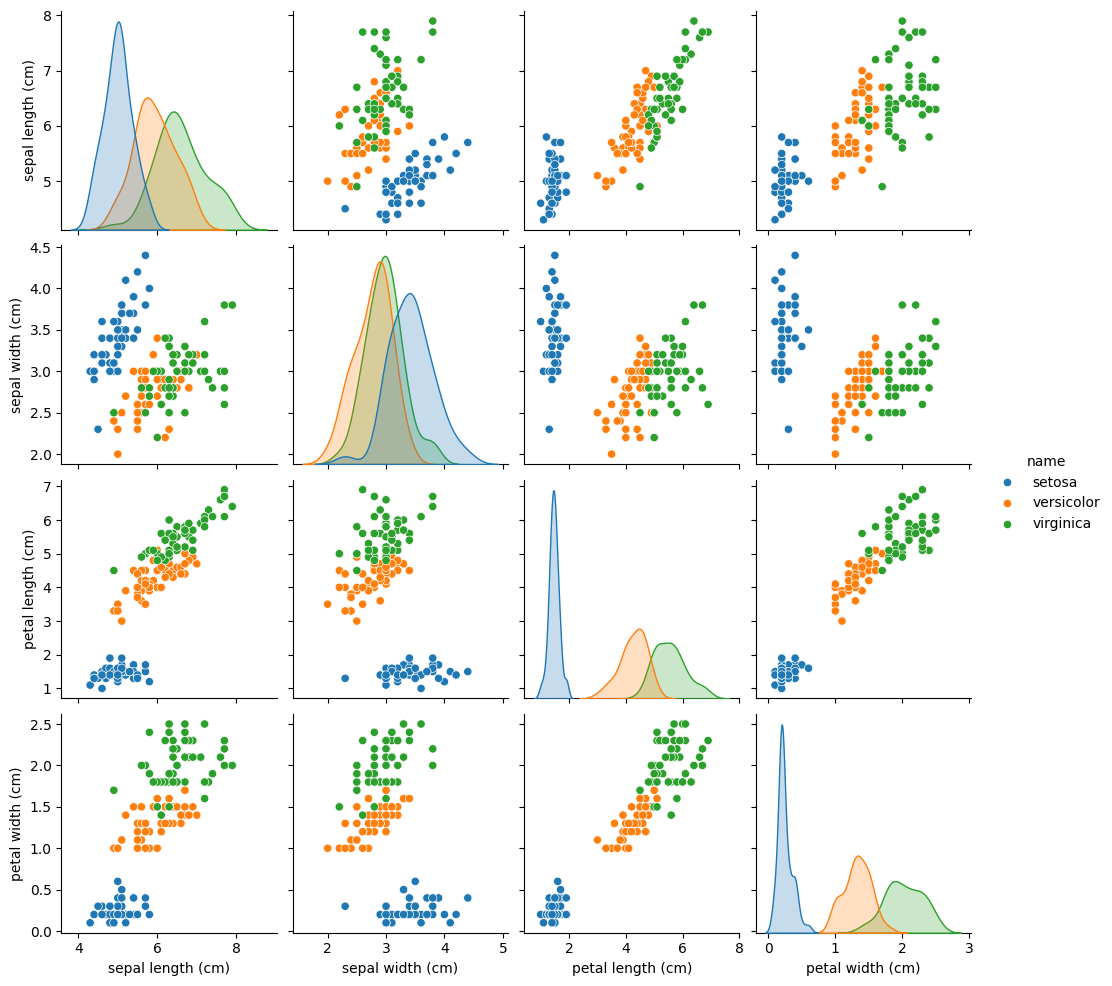

In [4]:
sns.pairplot(iris_frame[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)','name']], hue = 'name')

**Проверим данные на наличие пропусков**

In [5]:
iris_frame.isnull().any().any()

False

**Так как в наших данных нет пропусков, мы переходим к разделению данных на тестовую и обучающую выборки**

In [6]:
x = iris_frame.drop(columns=['target', 'name'])
y = iris_frame['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

print("Размер тренировочных данных (x_train):", x_train.shape)
print("Размер тестовых данных (x_test):", x_test.shape)
print("Размер тренировочных меток (y_train):", y_train.shape)
print("Размер тестовых меток (y_test):", y_test.shape)

Размер тренировочных данных (x_train): (105, 4)
Размер тестовых данных (x_test): (45, 4)
Размер тренировочных меток (y_train): (105,)
Размер тестовых меток (y_test): (45,)


# **Обучение модели с помощью логистической регрессии**

In [7]:
logistic_regression_model = LogisticRegression(max_iter=125)
logistic_regression_model.fit(x_train, y_train)

LogisticRegression(max_iter=125)

**Предсказание на тестовой выборке**

In [8]:
y_logistic_pred = logistic_regression_model.predict(x_test)

In [9]:
accuracy = accuracy_score(y_test, y_logistic_pred)
print(f'Accuracy: {accuracy:.10f}')

Accuracy: 0.9777777778


**Так как accuracy вышел слишком хорошим ипользуем cross-validation**

In [10]:
cross_val_logistic = cross_val_score(logistic_regression_model, x, y, cv=5)
print(f'Cross-Validation Scores: {cross_val_logistic}')
print(f'Mean Cross-Validation Score: {cross_val_logistic.mean():.10f}')

Cross-Validation Scores: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Mean Cross-Validation Score: 0.9733333333


# **Обучим модель с помощью SVM**

In [11]:
SVM_model = SVC(kernel='linear')
SVM_model.fit(x_train, y_train)

SVC(kernel='linear')

**Проверим результат обучения на метрике *accuracy***

In [12]:
y_SVM_pred = SVM_model.predict(x_test)
accuracy = accuracy_score(y_test, y_SVM_pred)
print(f'Accuracy: {accuracy:.10f}')

Accuracy: 0.9777777778


**Проверим результат обучения на метрике *cross validation***

In [13]:
cross_val_SVM = cross_val_score(SVM_model, x, y, cv=5)
print(f'Cross-Validation Scores: {cross_val_SVM}')
print(f'Mean Cross-Validation Score: {cross_val_SVM.mean():.10f}')

Cross-Validation Scores: [0.96666667 1.         0.96666667 0.96666667 1.        ]
Mean Cross-Validation Score: 0.9800000000
